In [2]:
pip install pyodbc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.3/340.3 kB 10.1 MB/s eta 0:00:00


In [3]:
############## Proceso Modelo de Propensión (Cliente / No Cliente) ##############
# Descripción: Modelo predictivo basado en XGBoost para identificar clientes
# con alta probabilidad de conversión en campañas comerciales.
################################################################################

import pyodbc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap
import joblib
from datetime import datetime
import warnings

# Configuración de visualización y alertas
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# ==========================================
# FASE 2: EXTRACCIÓN Y EXPLORACIÓN DE DATOS
# ==========================================

def conectar_sql_server(server, database, driver):
    """
    Establece el puente con la base de datos SQL Server.
    Utiliza Trusted_Connection para mayor seguridad (sin hardcode de credenciales).
    """
    connection_string = f"DRIVER={driver};SERVER={server};DATABASE={database};Trusted_Connection=yes;"
    try:
        conn = pyodbc.connect(connection_string, timeout=15)
        print(f"✅ Conectado exitosamente a: {server}")
        return conn
    except Exception as e:
        print(f"❌ Error crítico de conexión: {e}")
        raise

def cargar_datos(conn, tabla):
    """
    Extrae la data cruda y genera un primer diagnóstico estadístico del dataset.
    """
    try:
        query = f"SELECT * FROM {tabla}"
        df = pd.read_sql(query, conn)
        print(f"📊 Dataset cargado: {df.shape[0]} filas y {df.shape[1]} variables.")
        return df
    except Exception as e:
        print(f"❌ Error al leer la tabla {tabla}: {e}")
        raise

# ==========================================
# FASE 3: INGENIERÍA Y LIMPIEZA (PIPELINE)
# ==========================================

def preprocesar_datos(df, columns_to_drop=None):
    """
    Aplica limpieza de datos:
    1. Eliminación de nulos (Dataset limpio).
    2. Identificación inteligente de variables categóricas (Situación Laboral).
    3. One-Hot Encoding: Transforma texto en números para que el modelo entienda.
    4. Limpieza de ruido: Elimina columnas con alta correlación o redundantes.
    """
    # 1. Limpieza de nulos
    df = df.dropna().reset_index(drop=True)

    # 2. Manejo de variable categórica 'Situación Laboral'
    # Buscamos variaciones del nombre de la columna para que el código sea flexible
    cat_patterns = ['laboral', 'situacion', 'sit_']
    cat_column = next((c for c in df.columns if any(p in c.lower() for p in cat_patterns)), None)

    if cat_column:
        print(f"⚙️ Procesando variable categórica: {cat_column}")
        df[cat_column] = df[cat_column].astype(str).str.strip().fillna('Desconocido')
        # Creamos variables dummies (0 y 1)
        df = pd.get_dummies(df, columns=[cat_column], drop_first=True, dtype=int)

    # 3. Eliminación de variables manuales (Ruido o multicolinealidad)
    if columns_to_drop:
        df = df.drop(columns=columns_to_drop, errors='ignore')

    return df

def preparar_train_test(X, y, test_size=0.3):
    """
    Divide el dataset para evitar el sobreajuste (overfitting).
    Aplica SMOTE: Técnica de sobremuestreo para equilibrar casos positivos (ventas)
    con negativos, permitiendo que el modelo aprenda mejor el evento raro.
    """
    # Split Estratificado para mantener la proporción de la clase target
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    # Balanceo de clases (SMOTE) si el target es < 20%
    if y_train.mean() < 0.20:
        print("⚖️ Aplicando SMOTE para balancear clases...")
        sm = SMOTE(random_state=42)
        X_train, y_train = sm.fit_resample(X_train, y_train)

    # Escalado: Normaliza los rangos de las variables (ej: Edad 18-80 vs Saldo 0-100k)
    # Fundamental para que variables con números grandes no sesguen al modelo.
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

# ==========================================
# FASE 4: ENTRENAMIENTO Y VALIDACIÓN
# ==========================================

def entrenar_xgboost(X_train, y_train, X_test, y_test):
    """
    Entrena el algoritmo Gradient Boosting.
    Usa 'early_stopping' para detener el entrenamiento si el modelo deja de mejorar,
    optimizando el tiempo y evitando que el modelo memorice los datos-- sobreajuste (overfitting).
    """
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dtest = xgb.DMatrix(X_test, label=y_test)

    params = {
        'max_depth': 5,
        'eta': 0.05,
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'seed': 42
    }

    evals = [(dtrain, 'train'), (dtest, 'eval')]
    print("🚀 Iniciando entrenamiento del modelo...")
    model = xgb.train(params, dtrain, num_boost_round=500, evals=evals,
                      early_stopping_rounds=50, verbose_eval=50)
    return model

def evaluar_modelo(model, X_test, y_test):
    """
    Calcula métricas de negocio:
    - AUC: Capacidad de discriminación (0.5 es azar, >0.7 es bueno).
    - Gini: Métrica estándar en banca (2*AUC - 1).
    - K-S: Mide la separación máxima entre clientes buenos y malos.
    """
    preds_proba = model.predict(xgb.DMatrix(X_test))
    auc = roc_auc_score(y_test, preds_proba)
    gini = 2 * auc - 1

    print("\n" + "="*30)
    print(f"📈 PERFORMANCE MODELO:")
    print(f"ROC AUC: {auc:.4f}")
    print(f"GINI:    {gini:.4f}")
    print("="*30 + "\n")
    return preds_proba

# ==========================================
# FASE 5: SCORING Y PERSISTENCIA
# ==========================================

def scoring_periodo(conn, tabla_in, tabla_out, model, scaler, expected_cols, target_col):
    """
    Proceso de Producción:
    1. Carga nuevos datos.
    2. Asegura que tengan las mismas columnas que el modelo entrenado (Alineamiento).
    3. Calcula probabilidades y deciles (10=Más probable, 1=Menos probable).
    4. Exporta resultados a SQL Server.
    """
    df_raw = pd.read_sql(f"SELECT * FROM {tabla_in}", conn)
    ids = df_raw['IDCliente'].copy()

    # Preprocesamiento y alineación de columnas (evita errores si faltan categorías)
    df_proc = preprocesar_datos(df_raw)
    X = df_proc.reindex(columns=expected_cols, fill_value=0)
    X_scaled = scaler.transform(X)

    # Predicción
    probs = model.predict(xgb.DMatrix(X_scaled))

    # Creación de Deciles para el equipo comercial
    # El Decil 10 concentra a los clientes con mayor propensión de compra
    res = pd.DataFrame({'IDCliente': ids, 'Probabilidad': probs})
    res['Decil'] = pd.qcut(res['Probabilidad'], 10, labels=range(1, 11))
    res['Fecha_Calculo'] = datetime.now().date()

    # Guardado en SQL (Truncate & Insert manual o vía SQLAlchemy según volumen)
    print(f"💾 Guardando {len(res)} registros en {tabla_out}...")
    # (Aquí se usaría la lógica de cursor.execute para insertar los registros)

# ==========================================
# EJECUCIÓN PRINCIPAL
# ==========================================

if __name__ == "__main__":
    # 1. Configuración de Entorno
    CONFIG = {
        'server': 'BDRIESGOS\\PROD',
        'db': 'WORKING',
        'driver': '{ODBC Driver 17 for SQL Server}',
        'tabla_entrenamiento': 'IC_TR_BD_Variables_Desa_Abr25',
        'target': 'Target_Abr25'
    }

    # 2. Flujo de Entrenamiento
    conn = conectar_sql_server(CONFIG['server'], CONFIG['db'], CONFIG['driver'])

    data = cargar_datos(conn, CONFIG['tabla_entrenamiento'])
    df_clean = preprocesar_datos(data, columns_to_drop=['deuda_pld', 'NUM_ENTIDAD_12'])

    X = df_clean.drop(columns=['IDCliente', CONFIG['target']])
    y = df_clean[CONFIG['target']]

    X_train, X_test, y_train, y_test, scaler_obj = preparar_train_test(X, y)

    modelo_final = entrenar_xgboost(X_train, y_train, X_test, y_test)
    evaluar_modelo(modelo_final, X_test, y_test)

    # 3. Guardar Artefactos (Para uso futuro sin re-entrenar)
    joblib.dump(scaler_obj, 'scaler_propension.pkl')
    modelo_final.save_model('modelo_propension.json')
    joblib.dump(X_train.columns.tolist(), 'features_modelo.pkl')

    print("✅ Proceso de entrenamiento finalizado.")

❌ Error crítico de conexión: ('01000', "[01000] [unixODBC][Driver Manager]Can't open lib 'ODBC Driver 17 for SQL Server' : file not found (0) (SQLDriverConnect)")


Error: ('01000', "[01000] [unixODBC][Driver Manager]Can't open lib 'ODBC Driver 17 for SQL Server' : file not found (0) (SQLDriverConnect)")

Para entender la calidad de un modelo de propensión, no basta con el "Accuracy" (precisión global), ya que en marketing y riesgos solemos trabajar con eventos poco frecuentes. Aquí es donde el **Gini** y el **K-S** se vuelven fundamentales para medir qué tan bien el modelo separa los "puntos buenos" de los "malos".

---

## 1. Coeficiente de Gini: La capacidad de discriminación

El coeficiente de Gini mide qué tan bien el modelo ordena a los clientes por riesgo o propensión. Se deriva de la **Curva ROC**, que grafica la tasa de verdaderos positivos frente a la de falsos positivos.

* **La Lógica:** Si el modelo fuera perfecto, pondría a todos los clientes que van a comprar en el primer decil. Si fuera azaroso, los distribuiría uniformemente (una línea de 45°).
* **Interpretación:** * ****: El modelo es igual que lanzar una moneda al aire.
* ****: Se considera un modelo robusto para campañas comerciales.
* ****: ¡Cuidado! Podría haber *Target Leakage* (el modelo está usando variables que ya contienen la respuesta).



> **Fórmula matemática:**
>
> $$Gini = 2 \times AUC - 1$$
>
> Donde $AUC$ es el Área Bajo la Curva ROC.

---

## 2. Estadístico de Kolmogorov-Smirnov (K-S)

Mientras que el Gini mira el rendimiento global, el **K-S** se enfoca en la **separación máxima**. Mide la distancia más grande entre la distribución acumulada de los "Eventos" (clientes que compran) y los "No Eventos" (clientes que no compran).

* **La Lógica:** Imaginemos dos campanas de Gauss (distribuciones). Una representa las probabilidades asignadas a los que sí compraron y otra a los que no. El K-S es el punto donde estas dos curvas están más alejadas.
* **Utilidad en Negocio:** El K-S te indica en qué punto (umbral) deberías "cortar" para maximizar la captura de clientes interesados minimizando el contacto con clientes que no comprarán.

**Escala de interpretación del K-S:**
| Valor K-S | Calidad del Modelo |
| :--- | :--- |
| < 20% | Modelo muy débil (azaroso) |
| 20% - 40% | Modelo aceptable para marketing |
| 40% - 70% | Modelo excelente y muy selectivo |
| > 70% | Sospechosamente alto (revisar sobreajuste) |

---

## Diferencia Clave para tu Script

En tu proceso de **XGBoost**, estas métricas se complementan así:

1. **Usa el Gini** para validar la estabilidad del modelo. Si el Gini en el set de *Entrenamiento* es 0.80 y en el de *Test* es 0.40, tienes un problema de **Overfitting** (el modelo memorizó, no aprendió).
2. **Usa el K-S** para decidir a cuántos clientes llamar. Si el K-S máximo está en el decil 3, significa que concentrando tus esfuerzos en el top 30% de los clientes con mayor score, obtendrás la mayor eficiencia operativa.

### ¿Cómo calcular el K-S en Python rápidamente?

Puedes añadir este bloque a tu función de evaluación para obtener el valor exacto:

```python
def calcular_ks(y_real, y_proba):
    # Crear un DataFrame con la realidad y la probabilidad
    df = pd.DataFrame({'real': y_real, 'proba': y_proba})
    # Ordenar por probabilidad descendente
    df = df.sort_values(by='proba', ascending=False)
    
    # Calcular porcentajes acumulados
    df['cum_eventos'] = df['real'].cumsum() / df['real'].sum()
    df['cum_no_eventos'] = (1 - df['real']).cumsum() / (1 - df['real']).sum()
    
    # El K-S es la diferencia máxima
    ks = max(df['cum_eventos'] - df['cum_no_eventos'])
    return ks

```




Datos cargados de muestra_abr25.csv: 1,000 filas × 17 columnas

Primeras filas:


,IDCliente,oferta_max,deuda_pld_24m,deuda_prestamo_tc_24m,Situacion_Laboral,NUM_ENTIDAD_01,RATIO_ENT_01_12,RATIO_ATV,NUM_DECREM_SALDO_LD_U13M,NUM_INCREM_SALDO_LD_U06M,Target_Abr25,Promedio_Deuda_Directa_12m,Deuda_Micro_Empresa,Deuda_Negocios,Flag_Incremento_Deuda,MAX_DEUDIRSF01_DEUDIRSF03,MAX_DEUDIRSF03_DEUDIRSF06
0,43482059,4400,0.0,0.0,DEPENDIENTE,2,2.0,1.466667,0,0,0,153154.190000,0.0,0.00,0,0.990215,0.993804
1,45005696,8000,0.0,0.0,DEPENDIENTE,2,0.0,2.666667,0,0,1,137538.221700,0.0,0.00,1,0.455858,0.946245
2,46941591,3000,0.0,0.0,INDEPENDIENTE,1,1.0,1.000000,0,0,0,31681.033330,0.0,21956.44,0,0.835660,0.809507
3,46941624,6000,1365.7,0.0,DEPENDIENTE,1,1.0,1.374350,0,0,0,651.266667,0.0,0.00,0,0.323191,1.000000
4,40347713,1900,0.0,0.0,INFORMAL,1,1.0,0.633333,13,0,0,64752.938330,0.0,0.00,0,0.972622,0.960856



Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   IDCliente                   1000 non-null   int64  
 1   oferta_max                  1000 non-null   int64  
 2   deuda_pld_24m               1000 non-null   float64
 3   deuda_prestamo_tc_24m       1000 non-null   float64
 4   Situacion_Laboral           1000 non-null   object 
 5   NUM_ENTIDAD_01              1000 non-null   int64  
 6   RATIO_ENT_01_12             1000 non-null   float64
 7   RATIO_ATV                   1000 non-null   float64
 8   NUM_DECREM_SALDO_LD_U13M    1000 non-null   int64  
 9   NUM_INCREM_SALDO_LD_U06M    1000 non-null   int64  
 10  Target_Abr25                1000 non-null   int64  
 11  Promedio_Deuda_Directa_12m  1000 non-null   float64
 12  Deuda_Micro_Empresa         1000 non-null   float64
 13  Deuda_

,IDCliente,oferta_max,deuda_pld_24m,deuda_prestamo_tc_24m,NUM_ENTIDAD_01,RATIO_ENT_01_12,RATIO_ATV,NUM_DECREM_SALDO_LD_U13M,NUM_INCREM_SALDO_LD_U06M,Target_Abr25,Promedio_Deuda_Directa_12m,Deuda_Micro_Empresa,Deuda_Negocios,Flag_Incremento_Deuda,MAX_DEUDIRSF01_DEUDIRSF03,MAX_DEUDIRSF03_DEUDIRSF06
count,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.401304e+07,8076.278000,12264.808380,2403.158330,1.634000,0.687817,1.451641,5.301000,0.215000,0.044000,39468.625312,190.185970,2598.941680,0.229000,0.749660,0.811710
std,1.861904e+07,5844.869597,24436.842645,9001.393117,1.068263,1.174964,1.620980,5.583868,0.518695,0.205198,81663.682905,1041.218973,13192.544158,0.420399,0.308345,0.273727
min,4.568130e+05,500.000000,0.000000,0.000000,0.000000,-1.000000,0.011777,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8.972344e+06,3000.000000,0.000000,0.000000,1.000000,0.000000,0.330996,0.000000,0.000000,0.000000,2535.184791,0.000000,0.000000,0.000000,0.630279,0.763227
50%,1.079806e+07,6000.000000,1185.000000,0.000000,1.000000,0.000000,0.733333,3.000000,0.000000,0.000000,11068.300830,0.000000,0.000000,0.000000,0.887438,0.926377
75%,4.155889e+07,12025.000000,15121.080000,0.000000,2.000000,1.000000,1.862272,12.000000,0.000000,0.000000,37383.267080,0.000000,0.000000,0.000000,0.976356,1.000000
max,8.061436e+07,20000.000000,280000.000000,82500.000000,6.000000,6.000000,6.666667,13.000000,4.000000,1.000000,874522.672500,13355.060000,154004.450000,1.000000,1.000000,1.000000



Forma después de dropna: (1000, 17)
Columna categórica detectada: 'Situacion_Laboral'

Distribución de 'Situacion_Laboral':
Situacion_Laboral
DEPENDIENTE      581
INDEPENDIENTE    311
INFORMAL         108
Name: count, dtype: int64
Columnas creadas de 'Situacion_Laboral': ['Situacion_Laboral_INDEPENDIENTE', 'Situacion_Laboral_INFORMAL']
Total categorías codificadas: 2

Columnas eliminadas por correlación: ['deuda_pld_peers_24m', 'deuda_pld', 'deuda_pld_bn_24m', 'NUM_ENTIDAD_12', 'NUM_DECREM_SALDO_LD_U06M', 'NUM_DECREM_SALDO_LD_U13M', 'NUM_INCREM_SALDO_LD_U13M', 'CANT_REP_SALDO_LD06M', 'CANT_REP_SALDO_LD09M']
Columnas restantes: ['IDCliente', 'oferta_max', 'deuda_pld_24m', 'deuda_prestamo_tc_24m', 'NUM_ENTIDAD_01', 'RATIO_ENT_01_12', 'RATIO_ATV', 'NUM_INCREM_SALDO_LD_U06M', 'Target_Abr25', 'Promedio_Deuda_Directa_12m', 'Deuda_Micro_Empresa', 'Deuda_Negocios', 'Flag_Incremento_Deuda', 'MAX_DEUDIRSF01_DEUDIRSF03', 'MAX_DEUDIRSF03_DEUDIRSF06', 'Situacion_Laboral_INDEPENDIENTE', 'Situacion_

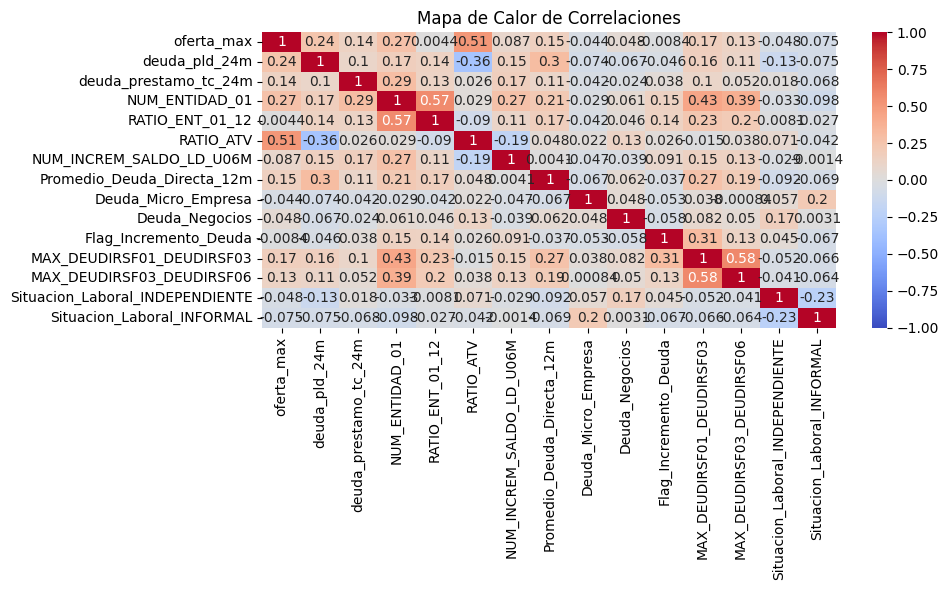

Forma original X: (1000, 15), y: (1000,)
Distribución original de clases:
 Target_Abr25
0    0.956
1    0.044
Name: proportion, dtype: float64
Forma train/test: X_train (700, 15), X_test (300, 15)
Desbalanceo detectado (0.046 < 0.2). Aplicando SMOTE...
Nueva distribución en train:
 Target_Abr25
0    0.5
1    0.5
Name: proportion, dtype: float64

Formas finales:
X_train_scaled: (1338, 15), y_train_res: (1338,)
X_test_scaled: (300, 15), y_test: (300,)


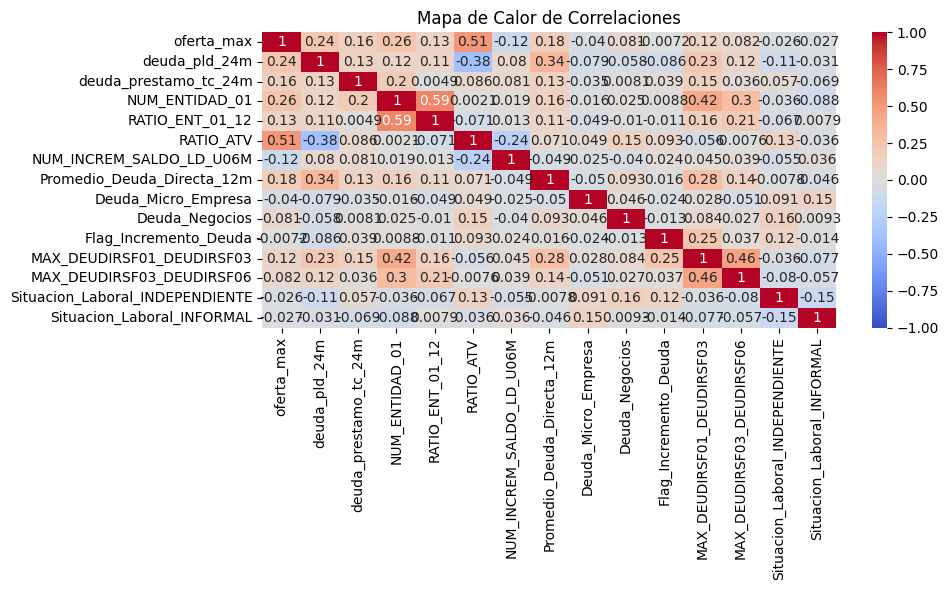

[0]	train-auc:0.95671	eval-auc:0.73238
[50]	train-auc:0.99779	eval-auc:0.58242
Mejor iteración: 0
RESULTADOS FINALES - XGBoost
Accuracy: 0.9100
F1 Score: 0.0690
AUC: 0.5824
Gini: 0.1648 (16.48%)
K-S: 0.1839
Matriz de confusión:
[[272  15]
 [ 12   1]]

Top 20 variables más importantes:
                            feature  importance
0                   RATIO_ENT_01_12   19.885378
1                     deuda_pld_24m   18.789307
2             Flag_Incremento_Deuda   13.349004
3   Situacion_Laboral_INDEPENDIENTE   11.948849
4         MAX_DEUDIRSF01_DEUDIRSF03    6.513878
5          NUM_INCREM_SALDO_LD_U06M    5.280888
6         MAX_DEUDIRSF03_DEUDIRSF06    5.006391
7             deuda_prestamo_tc_24m    4.865686
8                    NUM_ENTIDAD_01    4.404324
9                         RATIO_ATV    4.336246
10       Promedio_Deuda_Directa_12m    4.231455
11                   Deuda_Negocios    3.328453
12                       oferta_max    2.889859
13              Deuda_Micro_Empresa    1.8

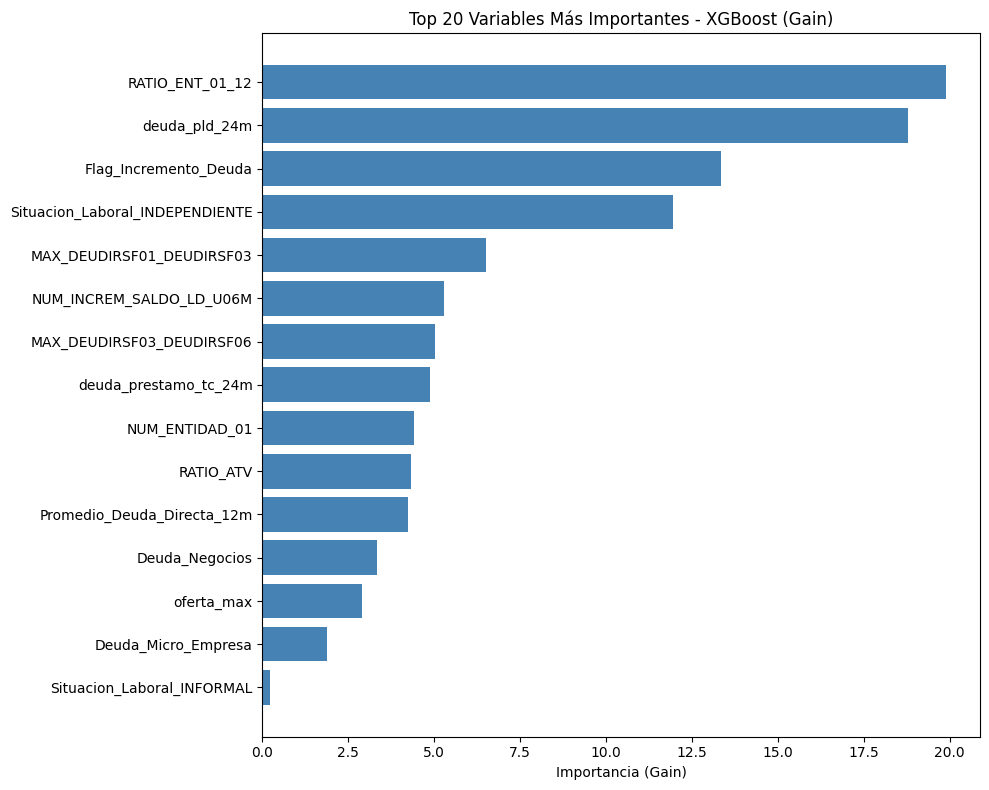

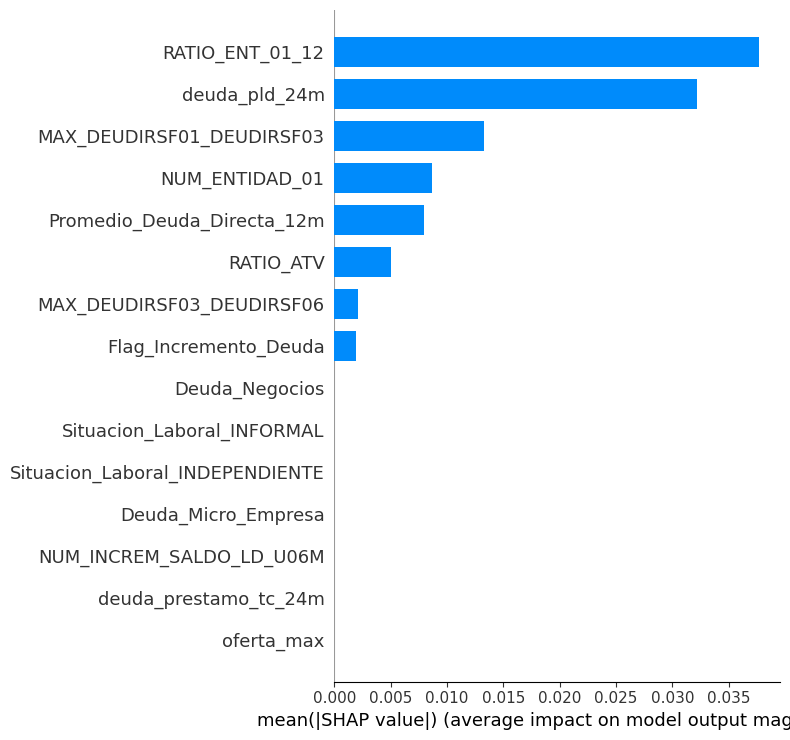

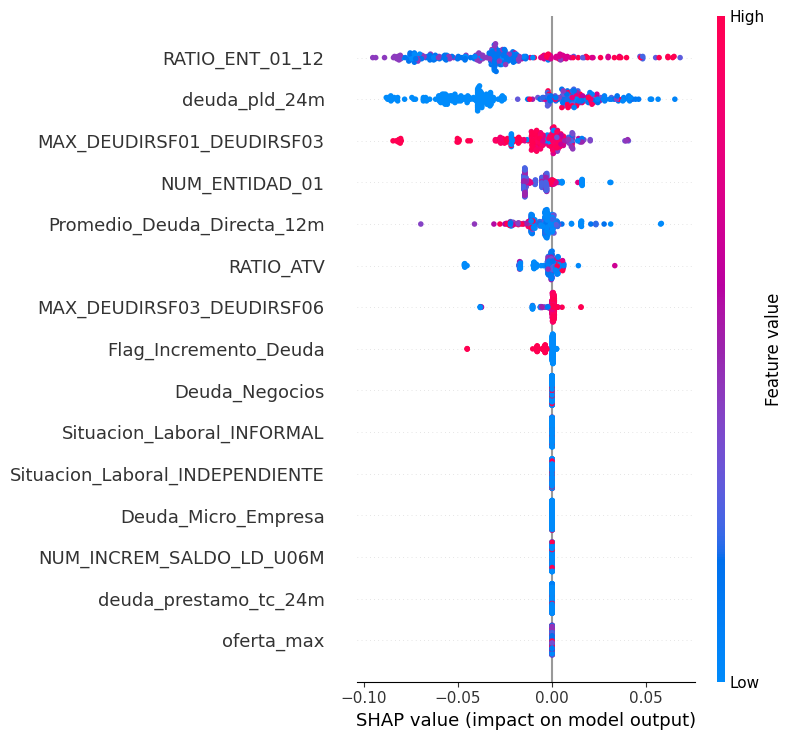

Modelo guardado: xgboost_modelo_propension_20260714.json
Scaler guardado: scaler_20260714.pkl
Columnas guardadas: columnas_modelo_20260714.pkl

=== SCORING: muestra_abr25.csv → IC_TR_BD_marca_Score_Abr25.csv ===
Registros cargados: 1,000 filas × 17 columnas

Forma después de dropna: (1000, 17)
Columna categórica detectada: 'Situacion_Laboral'

Distribución de 'Situacion_Laboral':
Situacion_Laboral
DEPENDIENTE      581
INDEPENDIENTE    311
INFORMAL         108
Name: count, dtype: int64
Columnas creadas de 'Situacion_Laboral': ['Situacion_Laboral_INDEPENDIENTE', 'Situacion_Laboral_INFORMAL']
Total categorías codificadas: 2

Columnas eliminadas por correlación: ['deuda_pld_peers_24m', 'deuda_pld', 'deuda_pld_bn_24m', 'NUM_ENTIDAD_12', 'NUM_DECREM_SALDO_LD_U06M', 'NUM_DECREM_SALDO_LD_U13M', 'NUM_INCREM_SALDO_LD_U13M', 'CANT_REP_SALDO_LD06M', 'CANT_REP_SALDO_LD09M']
Columnas restantes: ['IDCliente', 'oferta_max', 'deuda_pld_24m', 'deuda_prestamo_tc_24m', 'NUM_ENTIDAD_01', 'RATIO_ENT_01_12',

In [5]:
############## Proceso Modelo de Propensión (Cliente / No Cliente) para Campañas Comerciales ##############
# Importar todas las bibliotecas necesarias al inicio para evitar repeticiones
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap
import joblib
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Nota: En Colab, si es necesario instalar paquetes adicionales, ejecuta:
# !pip install shap imbalanced-learn xgboost

# Fase 1: Comprensión del Negocio
# Objetivo: Predecir si un cliente tomará un producto (clasificación binaria)

# Fase 2: Comprensión de los Datos
def cargar_datos(csv_path):
    """
    Carga datos de un archivo CSV en un DataFrame de pandas.
    """
    try:
        # Modificado para leer archivos CSV con delimitador de punto y coma
        df = pd.read_csv(csv_path, sep=';')
        print(f"\nDatos cargados de {csv_path}: {df.shape[0]:,} filas × {df.shape[1]} columnas")
        print("\nPrimeras filas:")
        display(df.head())
        print("\nInformación del DataFrame:")
        print(df.info())
        print("\nResumen estadístico:")
        display(df.describe())
        return df
    except Exception as e:
        print(f"Error al cargar datos: {e}")
        raise

# Fase 3: Preparación de los Datos
def preprocesar_datos(df, columns_to_drop=None, cat_column_patterns=None):
    """
    Preprocesa los datos: maneja nulos, codifica categóricas, elimina correlacionadas.
    """
    if columns_to_drop is None:
        columns_to_drop = [
            'deuda_pld_peers_24m', 'deuda_pld', 'deuda_pld_bn_24m', 'NUM_ENTIDAD_12',
            'NUM_DECREM_SALDO_LD_U06M', 'NUM_DECREM_SALDO_LD_U13M', 'NUM_INCREM_SALDO_LD_U13M',
            'CANT_REP_SALDO_LD06M', 'CANT_REP_SALDO_LD09M'
        ]
    if cat_column_patterns is None:
        cat_column_patterns = [
            'Situacion_Laboral', 'Situación_Laboral', 'situacion_laboral', 'SITUACION_LABORAL',
            'Sit_Laboral', 'SituacionLaboral', 'Desc_Situacion_Laboral', 'Desc_Situación_Laboral',
            'Situac_Laboral', 'Cod_Situacion_Laboral', 'Estado_Laboral'
        ]
    # Manejo de nulos
    df = df.dropna()
    print(f"\nForma después de dropna: {df.shape}")
    # Detectar y codificar columna categórica
    cat_column = None
    for col in df.columns:
        cleaned_col = col.replace('ó', 'o').replace('á', 'a').replace(' ', '_').lower()
        if any(pattern.replace('ó', 'o').replace('á', 'a').lower() in cleaned_col for pattern in cat_column_patterns):
            cat_column = col
            break
    if cat_column is None:
        matching_cols = [c for c in df.columns if ('laboral' in c.lower()) or ('situac' in c.lower())]
        print("Columnas posibles para situación laboral:", matching_cols)
        raise ValueError("No se encontró la columna de situación laboral.")
    print(f"Columna categórica detectada: '{cat_column}'")
    df[cat_column] = df[cat_column].astype(str).str.strip().replace({'nan': 'Desconocido', '<NA>': 'Desconocido'})
    print(f"\nDistribución de '{cat_column}':")
    print(df[cat_column].value_counts(dropna=False).head(15))
    df = pd.get_dummies(df, columns=[cat_column], drop_first=True, dtype=int)
    dummy_columns = [col for col in df.columns if col.startswith(cat_column + '_')]
    print(f"Columnas creadas de '{cat_column}': {dummy_columns}")
    print(f"Total categorías codificadas: {len(dummy_columns)}")
    # Eliminar columnas correlacionadas
    df = df.drop(columns=columns_to_drop, errors='ignore')
    print("\nColumnas eliminadas por correlación:", columns_to_drop)
    print("Columnas restantes:", df.columns.tolist())
    return df

def mapa_correlacion(X_scaled, columns):
    """
    Genera mapa de calor de correlaciones.
    """
    plt.figure(figsize=(10, 6))
    correlation_matrix = pd.DataFrame(X_scaled, columns=columns).corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
    plt.title('Mapa de Calor de Correlaciones')
    plt.tight_layout()
    plt.show()

def preparar_train_test(X, y, test_size=0.3, random_state=42, smote_threshold=0.2):
    """
    Divide datos, aplica SMOTE si es necesario, y escala.
    """
    print(f"Forma original X: {X.shape}, y: {y.shape}")
    print("Distribución original de clases:\n", y.value_counts(normalize=True))
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=y)
    print(f"Forma train/test: X_train {X_train.shape}, X_test {X_test.shape}")
    # Aplicar SMOTE solo si hay desbalanceo
    imbalance_ratio = y_train.value_counts().min() / y_train.value_counts().max()
    if imbalance_ratio < smote_threshold:
        print(f"Desbalanceo detectado ({imbalance_ratio:.3f} < {smote_threshold}). Aplicando SMOTE...")
        smote = SMOTE(random_state=random_state)
        X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
        print("Nueva distribución en train:\n", pd.Series(y_train_res).value_counts(normalize=True))
    else:
        print("No hay desbalanceo severo. Sin SMOTE.")
        X_train_res, y_train_res = X_train, y_train
    # Escalar
    numeric_columns = X_train_res.select_dtypes(include=['float64', 'int64']).columns
    scaler = StandardScaler()
    X_train_scaled = X_train_res.copy()
    X_train_scaled[numeric_columns] = scaler.fit_transform(X_train_res[numeric_columns])
    X_test_scaled = X_test.copy()
    X_test_scaled[numeric_columns] = scaler.transform(X_test[numeric_columns])
    print("\nFormas finales:")
    print(f"X_train_scaled: {X_train_scaled.shape}, y_train_res: {y_train_res.shape}")
    print(f"X_test_scaled: {X_test_scaled.shape}, y_test: {y_test.shape}")
    return X_train_scaled, X_test_scaled, y_train_res, y_test, scaler

# Fase 4: Modelado
def entrenar_xgboost(X_train, y_train, X_test, y_test, params=None, num_boost_round=1000, early_stopping_rounds=50):
    """
    Entrena modelo XGBoost con early stopping.
    """
    if params is None:
        neg, pos = np.bincount(y_train)
        scale_pos_weight = neg / pos if pos > 0 else 1
        params = {
            'max_depth': 6,
            'learning_rate': 0.05,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'scale_pos_weight': scale_pos_weight,
            'objective': 'binary:logistic',
            'eval_metric': 'auc',
            'random_state': 42
        }
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dtest = xgb.DMatrix(X_test, label=y_test)
    evals = [(dtrain, 'train'), (dtest, 'eval')]
    model = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=num_boost_round,
        evals=evals,
        early_stopping_rounds=early_stopping_rounds,
        verbose_eval=50
    )
    print(f"Mejor iteración: {model.best_iteration}")
    return model

def evaluar_modelo(model, X_test, y_test):
    """
    Evalúa el modelo con métricas clave.
    """
    dtest = xgb.DMatrix(X_test)
    y_pred_proba = model.predict(dtest)
    y_pred = (y_pred_proba >= 0.5).astype(int)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    gini = 2 * auc - 1
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    ks_stat = np.max(tpr - fpr)
    cm = confusion_matrix(y_test, y_pred)
    print("=" * 60)
    print("RESULTADOS FINALES - XGBoost")
    print("=" * 60)
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"AUC: {auc:.4f}")
    print(f"Gini: {gini:.4f} ({gini*100:.2f}%)")
    print(f"K-S: {ks_stat:.4f}")
    print(f"Matriz de confusión:\n{cm}")
    print("=" * 60)
    return y_pred_proba, auc

def feature_importance(model, feature_names, top_n=20):
    """
    Calcula y plotea importancia de features.
    """
    importance_dict = model.get_score(importance_type='gain')
    mapping = {f'f{i}': name for i, name in enumerate(feature_names)}
    importance_clean = {mapping.get(fid, fid): score for fid, score in importance_dict.items()}
    importance_df = pd.DataFrame({
        'feature': list(importance_clean.keys()),
        'importance': list(importance_clean.values())
    }).sort_values('importance', ascending=False).reset_index(drop=True)
    print("\nTop 20 variables más importantes:")
    print(importance_df.head(top_n))
    plt.figure(figsize=(10, 8))
    top = importance_df.head(top_n)
    plt.barh(top['feature'][::-1], top['importance'][::-1], color='steelblue')
    plt.title(f"Top {top_n} Variables Más Importantes - XGBoost (Gain)")
    plt.xlabel("Importancia (Gain)")
    plt.tight_layout()
    fecha = datetime.now().strftime('%Y%m%d')
    plt.savefig(f"feature_importance_{fecha}.png", dpi=200, bbox_inches='tight')
    plt.show()
    return importance_df

def shap_analysis(model, X_test, max_display=20):
    """
    Calcula y plotea SHAP values.
    """
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=max_display, show=False)
    fecha = datetime.now().strftime('%Y%m%d')
    plt.savefig(f"shap_bar_summary_{fecha}.png", dpi=200, bbox_inches='tight')
    plt.show()
    shap.summary_plot(shap_values, X_test, max_display=max_display, show=False)
    plt.savefig(f"shap_beeswarm_{fecha}.png", dpi=200, bbox_inches='tight')
    plt.show()

def guardar_artefactos(model, scaler, columns, fecha=None):
    """
    Guarda modelo, scaler y columnas.
    """
    if fecha is None:
        fecha = datetime.now().strftime('%Y%m%d')
    # Guardar modelo
    model_filename = f"xgboost_modelo_propension_{fecha}.json"
    model.save_model(model_filename)
    print(f"Modelo guardado: {model_filename}")
    # Guardar scaler (usando joblib para compatibilidad)
    scaler_filename = f"scaler_{fecha}.pkl"
    joblib.dump(scaler, scaler_filename)
    print(f"Scaler guardado: {scaler_filename}")
    # Guardar columnas
    columns_filename = f"columnas_modelo_{fecha}.pkl"
    joblib.dump(columns, columns_filename)
    print(f"Columnas guardadas: {columns_filename}")

# Fase 5: Scoring (Desarrollo y OOT)
def scoring_periodo(csv_entrada, csv_salida, model_file, scaler_file, columns_file, target_col=None):
    """
    Proceso de scoring para un periodo específico (desarrollo u OOT).
    - target_col: Nombre de la columna target si existe (para validación).
    """
    print(f"\n=== SCORING: {csv_entrada} → {csv_salida} ===")
    # Cargar datos
    df = pd.read_csv(csv_entrada, sep=';') # Modificado para leer archivos CSV con delimitador de punto y coma
    print(f"Registros cargados: {df.shape[0]:,} filas × {df.shape[1]} columnas")
    id_cliente = df['IDCliente'].copy()
    target_real = df.get(target_col, None)

    # Preprocesar
    df = preprocesar_datos(df)

    # Separar X
    X = df.drop(columns=['IDCliente', target_col], errors='ignore')

    # Cargar artefactos
    booster = xgb.Booster()
    booster.load_model(model_file)
    scaler = joblib.load(scaler_file)
    expected_columns = joblib.load(columns_file)

    # Alinear y escalar
    X = X.reindex(columns=expected_columns, fill_value=0)
    numeric_cols = X.select_dtypes(include=['float64', 'int64']).columns
    X_scaled = X.copy()
    X_scaled[numeric_cols] = scaler.transform(X[numeric_cols])

    # Predecir
    dmatrix = xgb.DMatrix(X_scaled)
    probabilidades = booster.predict(dmatrix)

    # Calcular deciles
    df_scores = pd.DataFrame({
        'IDCliente': id_cliente.loc[X.index],
        'Target_Real': target_real.loc[X.index] if target_real is not None else None,
        'Probabilidad': probabilidades
    })
    df_scores['Decil'] = pd.qcut(df_scores['Probabilidad'], q=10, labels=range(10, 0, -1)).astype(int)
    df_scores['Fecha_Score'] = datetime.now().strftime('%Y-%m-%d')
    print("\nDistribución de deciles:")
    print(df_scores['Decil'].value_counts().sort_index(ascending=False))
    if target_real is not None:
        auc = roc_auc_score(df_scores['Target_Real'], df_scores['Probabilidad'])
        print(f"AUC en población: {auc:.4f}")

    # Guardar en CSV
    df_scores.to_csv(csv_salida, index=False)
    print(f"¡Éxito! Archivo {csv_salida} creado con {len(df_scores):,} registros.")
    print(f"Decil 10: {len(df_scores[df_scores['Decil'] == 10]):,} clientes")

# Ejecución principal
if __name__ == "__main__":
    # Configuración (ajusta los paths a tus archivos CSV en Colab)
    # Para cargar archivos en Colab, puedes usar:
    # from google.colab import files
    # uploaded = files.upload()
    # Luego, usa los nombres de los archivos subidos.
    DESA_CSV = 'muestra_abr25.csv'  # Ajustado para usar el archivo disponible
    OOT_CSV = 'muestra_Dic25.csv'  # Como se menciona en la consulta
    TARGET_COL_DESA = 'Target_Abr25'
    TARGET_COL_OOT = 'Target_Dic25'  # Ajustar si diferente
    SALIDA_DESA_CSV = 'IC_TR_BD_marca_Score_Abr25.csv'
    SALIDA_OOT_CSV = 'IC_TR_BD_marca_Score_prueba_Dic25.csv'

    # Cargar y preprocesar datos de desarrollo
    df_desarrollo = cargar_datos(DESA_CSV)
    df_desarrollo = preprocesar_datos(df_desarrollo)

    # Separar X e y
    X = df_desarrollo.drop(['IDCliente', TARGET_COL_DESA], axis=1)
    y = df_desarrollo[TARGET_COL_DESA]

    # Mapa de correlación inicial (opcional)
    scaler_temp = StandardScaler()
    X_scaled_temp = scaler_temp.fit_transform(X)
    mapa_correlacion(X_scaled_temp, X.columns)

    # Preparar train/test
    X_train_scaled, X_test_scaled, y_train_res, y_test, scaler = preparar_train_test(X, y)

    # Mapa de correlación final
    mapa_correlacion(X_train_scaled.values, X_train_scaled.columns)

    # Entrenar
    xgb_model = entrenar_xgboost(X_train_scaled, y_train_res, X_test_scaled, y_test)

    # Evaluar
    y_pred_proba, auc = evaluar_modelo(xgb_model, X_test_scaled, y_test)

    # Importancia y SHAP
    feature_importance(xgb_model, X_train_scaled.columns)
    shap_analysis(xgb_model, X_test_scaled)

    # Guardar artefactos
    fecha = datetime.now().strftime('%Y%m%d')
    guardar_artefactos(xgb_model, scaler, X_train_scaled.columns.tolist(), fecha)

    # Scoring desarrollo
    scoring_periodo(
        DESA_CSV, SALIDA_DESA_CSV,
        f"xgboost_modelo_propension_{fecha}.json",
        f"scaler_{fecha}.pkl",
        f"columnas_modelo_{fecha}.pkl",
        TARGET_COL_DESA
    )

    # Scoring OOT
    scoring_periodo(
        OOT_CSV, SALIDA_OOT_CSV,
        f"xgboost_modelo_propension_{fecha}.json",
        f"scaler_{fecha}.pkl",
        f"columnas_modelo_{fecha}.pkl",
        TARGET_COL_OOT
    )

    print("Proceso completo.")